# Fused MoE operator benchmark

Compares the PyTorch expert-loop oracle with the Triton grouped-GEMM implementation. Results use the same per-GPU, per-operator timestamped archive as `operator_bench.ipynb`.

In [1]:
from pathlib import Path
import sys
import torch

ROOT = Path.cwd().resolve()
if ROOT.name == 'tests':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'tests') not in sys.path:
    sys.path.insert(0, str(ROOT / 'tests'))

from minitrain.model.ops import get_ops_backend
from operator_bench_utils import (
    BenchCase, bench_sweep, correctness_stats, plot_kernel_grid, save_benchmark_results,
    run_with_cuda_cleanup, to_summary_dataframe,
)

DEVICE = torch.device('cuda')
DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
PROVIDERS = ('torch', 'triton')
WARMUP_MS, REP_MS = 10, 50
BENCHMARK_CACHE_DIR = ROOT / 'tests' / 'benchmark_results'
FIG_DIR = ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)


## Router postprocess correctness

The fused path must match the Torch oracle for Top-K weights, expert probability statistics, z-loss, entropy, and the combined gradient from all differentiable outputs. Unsupported devices or deterministic mode intentionally use the backend fallback.

In [2]:
from minitrain.kernels.triton.router import is_router_postprocess_supported

torch.manual_seed(17)
TOKENS, ROUTER_EXPERTS, ROUTER_TOP_K = 257, 64, 2
def check_router_postprocess():
    base_logits = torch.randn(TOKENS, ROUTER_EXPERTS, device=DEVICE, dtype=torch.float32)
    weight_grad = torch.randn(TOKENS, ROUTER_TOP_K, device=DEVICE)
    probability_grad = torch.randn(ROUTER_EXPERTS, device=DEVICE)

    def run_router_with_grad(provider):
        logits = base_logits.detach().clone().requires_grad_(True)
        route = get_ops_backend(provider).router_postprocess(
            logits, ROUTER_TOP_K, normalize=True
        )
        objective = (
            (route.expert_weights * weight_grad).sum()
            + (route.probability_per_expert * probability_grad).sum()
            + 0.13 * route.z_loss
        )
        objective.backward()
        return route, logits.grad

    reference, reference_grad = run_router_with_grad('torch')
    candidate, candidate_grad = run_router_with_grad('triton')
    torch.testing.assert_close(candidate.expert_indices, reference.expert_indices)
    torch.testing.assert_close(candidate.expert_weights, reference.expert_weights, atol=2e-5, rtol=2e-5)
    torch.testing.assert_close(candidate.probability_per_expert, reference.probability_per_expert, atol=2e-5, rtol=2e-5)
    torch.testing.assert_close(candidate.z_loss, reference.z_loss, atol=2e-5, rtol=2e-5)
    torch.testing.assert_close(candidate.entropy, reference.entropy, atol=2e-5, rtol=2e-5)
    torch.testing.assert_close(candidate_grad, reference_grad, atol=5e-5, rtol=5e-5)
    previous_deterministic = torch.are_deterministic_algorithms_enabled()
    try:
        torch.use_deterministic_algorithms(True)
        assert not is_router_postprocess_supported(base_logits, ROUTER_TOP_K, True)
        deterministic_route = get_ops_backend('triton').router_postprocess(
            base_logits, ROUTER_TOP_K, normalize=True
        )
        torch.testing.assert_close(
            deterministic_route.expert_weights, reference.expert_weights
        )
    finally:
        torch.use_deterministic_algorithms(previous_deterministic)
    return is_router_postprocess_supported(base_logits, ROUTER_TOP_K, True)

native_router_path = run_with_cuda_cleanup(check_router_postprocess)
print('native Triton path:', native_router_path)
print('router forward and combined backward: OK')


native Triton path: False
router forward and combined backward: OK


## Dropless end-to-end MoE smoke

Capacity masking is disabled until dispatch compaction exists in every backend. This check runs a complete dropless MoE transformer backward through the selected backend, using BF16 when the GPU supports it and FP16 otherwise.

In [3]:
from minitrain.model.config import ModelConfig
from minitrain.model.transformer import MiniTransformer

def check_dropless_moe_backward():
    smoke_cfg = ModelConfig(
        vocab_size=128, seq_len=16, n_layers=2, n_heads=4, hidden_size=64,
        intermediate_size=128, ffn_type='moe', num_experts=8, experts_per_token=2,
    )
    model = MiniTransformer(
        smoke_cfg, get_ops_backend('triton'), activation_dtype=DTYPE
    ).to(DEVICE)
    input_ids = torch.randint(
        0, smoke_cfg.vocab_size, (2, smoke_cfg.seq_len), device=DEVICE
    )
    with torch.autocast('cuda', dtype=DTYPE):
        loss, _ = model(input_ids, input_ids)
    loss.backward()
    router_grads = [block.ffn.router.weight.grad for block in model.blocks]
    assert all(grad is not None and torch.isfinite(grad).all() for grad in router_grads)
    assert smoke_cfg.expert_capacity_factor is None

run_with_cuda_cleanup(check_dropless_moe_backward)
print('dropless end-to-end MoE backward: OK')


dropless end-to-end MoE backward: OK


## Router postprocess benchmark

raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\router-postprocess\2026-07-15T17-30-48.283723_00-00.json


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup,full_p50_ms,full_p95_ms,full_peak_mem_mb,full_speedup
0,router_postprocess,torch,8192,ok,True,True,0.0,0.0,0.713216,0.863746,6.282227,1.000000,0.668160,0.728422,5.781738,1.000000,1.278976,1.395200,8.438477,1.000000
1,router_postprocess,triton,8192,ok,True,True,0.0,0.0,0.711168,0.769843,6.282227,1.002880,0.714752,1.346099,5.781738,0.934814,1.924112,2.118195,8.438477,0.664710
2,router_postprocess,torch,131072,ok,True,True,0.0,0.0,9.365504,9.902029,100.500977,1.000000,4.402688,4.709017,92.500488,1.000000,12.094464,12.385177,135.000977,1.000000
3,router_postprocess,triton,131072,ok,True,True,0.0,0.0,7.920992,8.498064,100.500977,1.182365,4.382720,4.697079,92.500488,1.004556,12.292560,12.619552,135.000977,0.983885
4,router_postprocess,torch,524288,ok,True,True,0.0,0.0,31.219200,31.768627,402.000977,1.000000,16.699903,16.830158,370.000488,1.000000,47.550976,48.069378,540.000977,1.000000
5,router_postprocess,triton,524288,ok,True,True,0.0,0.0,31.220224,31.553638,402.000977,0.999967,16.683952,17.059534,370.000488,1.000956,47.551455,47.671041,540.000977,0.999990
6,router_postprocess,torch,1048576,ok,True,True,0.0,0.0,61.962751,62.609142,804.000977,1.000000,32.683519,33.227009,740.000488,1.000000,94.678528,95.165648,1080.000977,1.000000
7,router_postprocess,triton,1048576,ok,True,True,0.0,0.0,62.181313,62.615956,804.000977,0.996485,32.928766,33.230850,740.000488,0.992552,94.840832,95.417289,1080.000977,0.998289
8,router_postprocess,torch,2097152,ok,True,True,0.0,0.0,124.279808,125.212825,1608.000977,1.000000,65.399807,65.934747,1480.000488,1.000000,189.548035,190.036588,2160.000977,1.000000
9,router_postprocess,triton,2097152,ok,True,True,0.0,0.0,124.464130,124.847156,1608.000977,0.998519,65.282528,65.686679,1480.000488,1.001796,189.476868,189.982465,2160.000977,1.000376


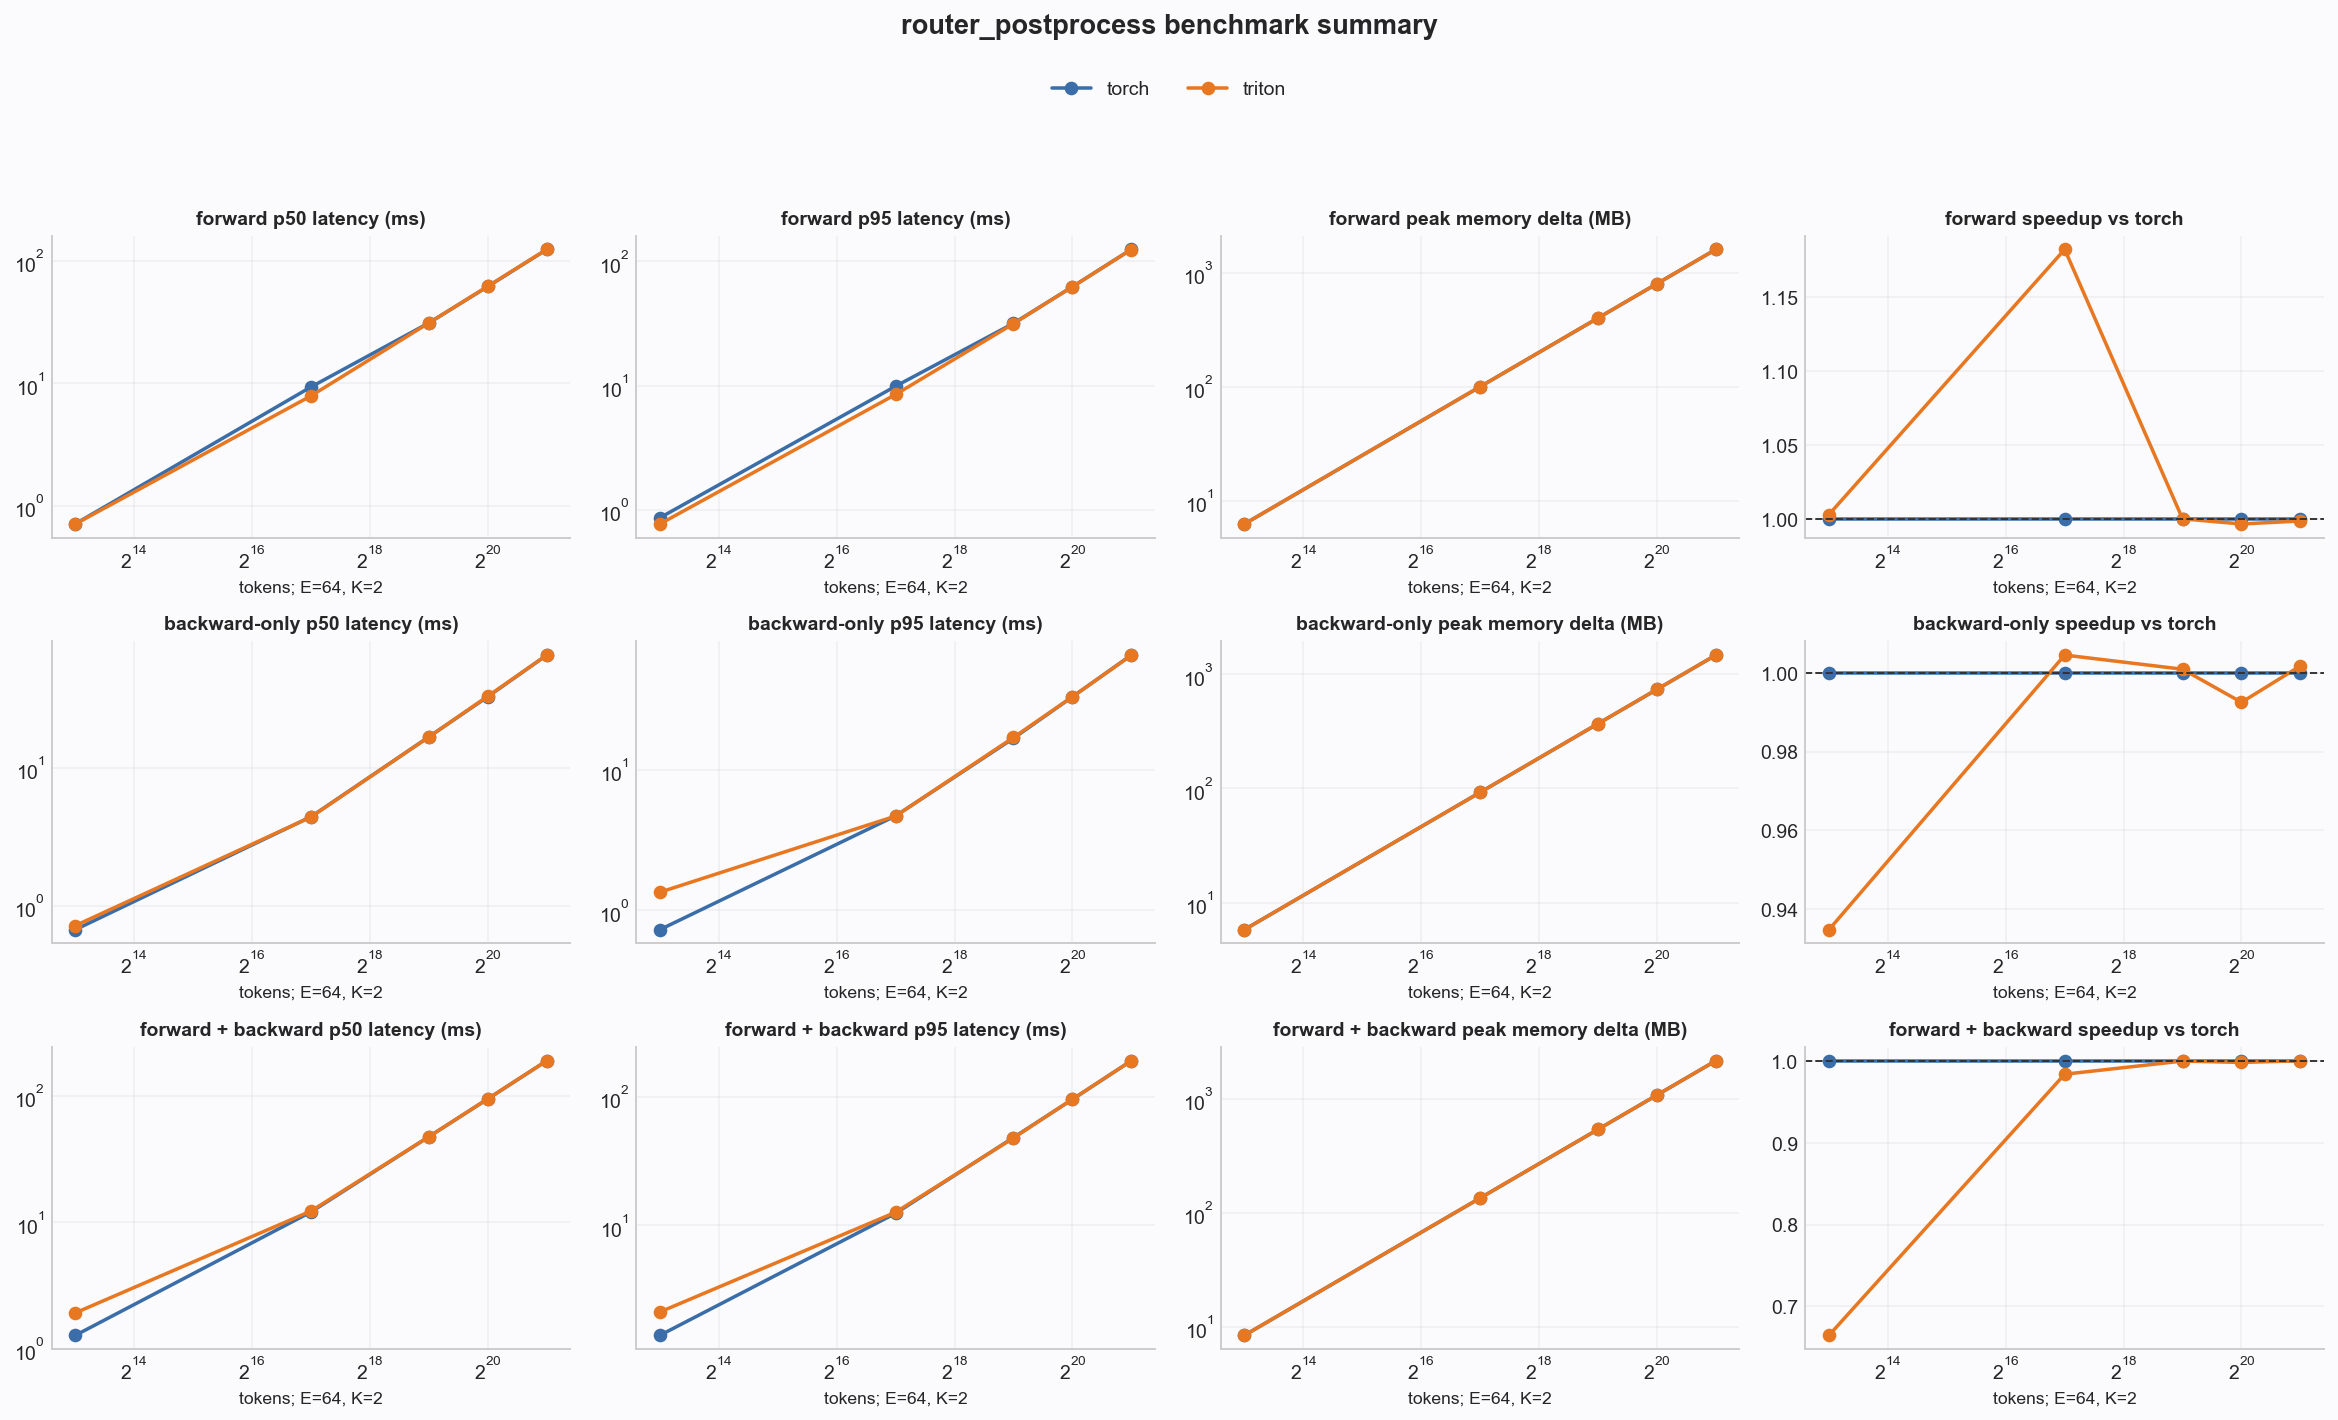

In [4]:
def make_router_case(tokens):
    return BenchCase(
        tensors={'logits': torch.randn(tokens, ROUTER_EXPERTS, device=DEVICE, dtype=torch.float32)},
        grad_names=('logits',),
    )

def router_forward(provider, tensors):
    route = get_ops_backend(provider).router_postprocess(
        tensors['logits'], ROUTER_TOP_K, normalize=True
    )
    return route.expert_weights, route.probability_per_expert, route.z_loss

router_rows = bench_sweep(
    kernel='router_postprocess', providers=PROVIDERS,
    sizes=(8192, 131072, 524288, 1048576, 2097152),
    size_label=f'tokens; E={ROUTER_EXPERTS}, K={ROUTER_TOP_K}',
    make_case=make_router_case, forward=router_forward,
    warmup_ms=WARMUP_MS, rep_ms=REP_MS, atol=5e-5, rtol=5e-5,
)
router_cache = save_benchmark_results(
    router_rows, benchmark='router_postprocess', cache_root=BENCHMARK_CACHE_DIR,
    metadata={'num_experts': ROUTER_EXPERTS, 'top_k': ROUTER_TOP_K},
)
print(f'raw benchmark data: {router_cache}')
display(to_summary_dataframe(router_rows))
_ = plot_kernel_grid(router_rows, save_path=FIG_DIR / 'router_postprocess_summary.png')


In [5]:
NUM_EXPERTS, HIDDEN, INTERMEDIATE, TOP_K = 8, 512, 1024, 2

def make_fused_moe_case(tokens):
    router_logits = torch.randn(tokens, NUM_EXPERTS, device=DEVICE)
    top_k_logits, top_k_index = torch.topk(router_logits, TOP_K, dim=-1)
    top_k_weights = torch.softmax(top_k_logits, dim=-1).to(DTYPE)
    return BenchCase(
        tensors={
            'x': torch.randn(tokens, HIDDEN, device=DEVICE, dtype=DTYPE),
            'gate_up_proj': torch.randn(NUM_EXPERTS, 2 * INTERMEDIATE, HIDDEN, device=DEVICE, dtype=DTYPE) * 0.02,
            'down_proj': torch.randn(NUM_EXPERTS, HIDDEN, INTERMEDIATE, device=DEVICE, dtype=DTYPE) * 0.02,
            'top_k_index': top_k_index.to(torch.int32),
            'top_k_weights': top_k_weights,
        },
        grad_names=('x', 'gate_up_proj', 'down_proj', 'top_k_weights'),
    )

def fused_moe_forward(provider, tensors):
    return get_ops_backend(provider).fused_moe(
        tensors['x'], tensors['gate_up_proj'], tensors['down_proj'],
        tensors['top_k_index'], tensors['top_k_weights'],
    )

def make_fused_moe_edge_case(tokens):
    edge_top_k = 3
    top_k_index = torch.tensor(
        [[(token + slot) % 2 for slot in range(edge_top_k)] for token in range(tokens)],
        device=DEVICE, dtype=torch.int32,
    )
    top_k_weights = torch.rand(tokens, edge_top_k, device=DEVICE, dtype=DTYPE)
    top_k_weights[::2, -1] = 0
    return BenchCase(
        tensors={
            'x': torch.randn(tokens, HIDDEN, device=DEVICE, dtype=DTYPE),
            'gate_up_proj': torch.randn(NUM_EXPERTS, 2 * INTERMEDIATE, HIDDEN, device=DEVICE, dtype=DTYPE) * 0.02,
            'down_proj': torch.randn(NUM_EXPERTS, HIDDEN, INTERMEDIATE, device=DEVICE, dtype=DTYPE) * 0.02,
            'top_k_index': top_k_index,
            'top_k_weights': top_k_weights,
        },
        grad_names=('x', 'gate_up_proj', 'down_proj', 'top_k_weights'),
    )

edge_stats = correctness_stats(
    make_fused_moe_edge_case, 33, 'triton', fused_moe_forward, atol=3e-2, rtol=8e-2,
)
assert edge_stats['fwd_correct'] and edge_stats['bwd_correct'], edge_stats
print('fused MoE skewed/empty-expert, K=3, zero-weight gradient probe: OK')


fused MoE skewed/empty-expert, K=3, zero-weight gradient probe: OK


raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\fused-moe\2026-07-15T17-33-06.653001_00-00.json


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup,full_p50_ms,full_p95_ms,full_peak_mem_mb,full_speedup
0,fused_moe,torch,8192,ok,True,True,0.0,0.0,10.571264,11.758797,26.614258,1.000000,18.791936,19.240808,22.546387,1.000000,29.005713,29.893223,208.473145,1.000000
1,fused_moe,triton,8192,ok,True,True,0.0,0.0,9.848320,10.647707,26.867676,1.073408,18.947040,19.427987,23.596191,0.991814,28.862976,30.079078,207.434082,1.004945
2,fused_moe,torch,32768,ok,True,True,0.0,0.0,28.273152,28.965939,105.450195,1.000000,58.535423,59.308541,55.756348,1.000000,87.922176,88.561406,803.062500,1.000000
3,fused_moe,triton,32768,ok,True,True,0.0,0.0,28.323839,28.982764,105.221191,0.998210,58.269552,58.892085,56.107910,1.004563,87.683582,88.503166,802.973633,1.002721
4,fused_moe,torch,65536,ok,True,True,0.0,0.0,52.477407,53.331148,209.817383,1.000000,106.176510,107.365425,104.219238,1.000000,161.487358,162.234354,1606.296387,1.000000
5,fused_moe,triton,65536,ok,True,True,0.0,0.0,52.367359,53.004122,210.618652,1.002101,106.851215,107.591937,104.219238,0.993686,161.804771,162.094290,1605.736816,0.998038
6,fused_moe,torch,98304,ok,True,True,0.0,0.0,77.401981,78.572953,315.240723,1.000000,161.638321,162.237959,152.328613,1.000000,240.942078,241.896802,2410.141113,1.000000
7,fused_moe,triton,98304,ok,True,True,0.0,0.0,77.043201,77.948162,315.408203,1.004657,161.067001,161.747554,152.328613,1.003547,241.251328,242.223642,2405.733398,0.998718
8,fused_moe,torch,114688,ok,True,True,0.0,0.0,89.562546,90.198822,369.412109,1.000000,186.756607,187.671201,176.383301,1.000000,279.998459,281.162270,2809.117188,1.000000
9,fused_moe,triton,114688,ok,True,True,0.0,0.0,89.595890,90.036021,367.485840,0.999628,186.542076,186.915782,176.681641,1.001150,279.950333,280.526569,2807.951660,1.000172


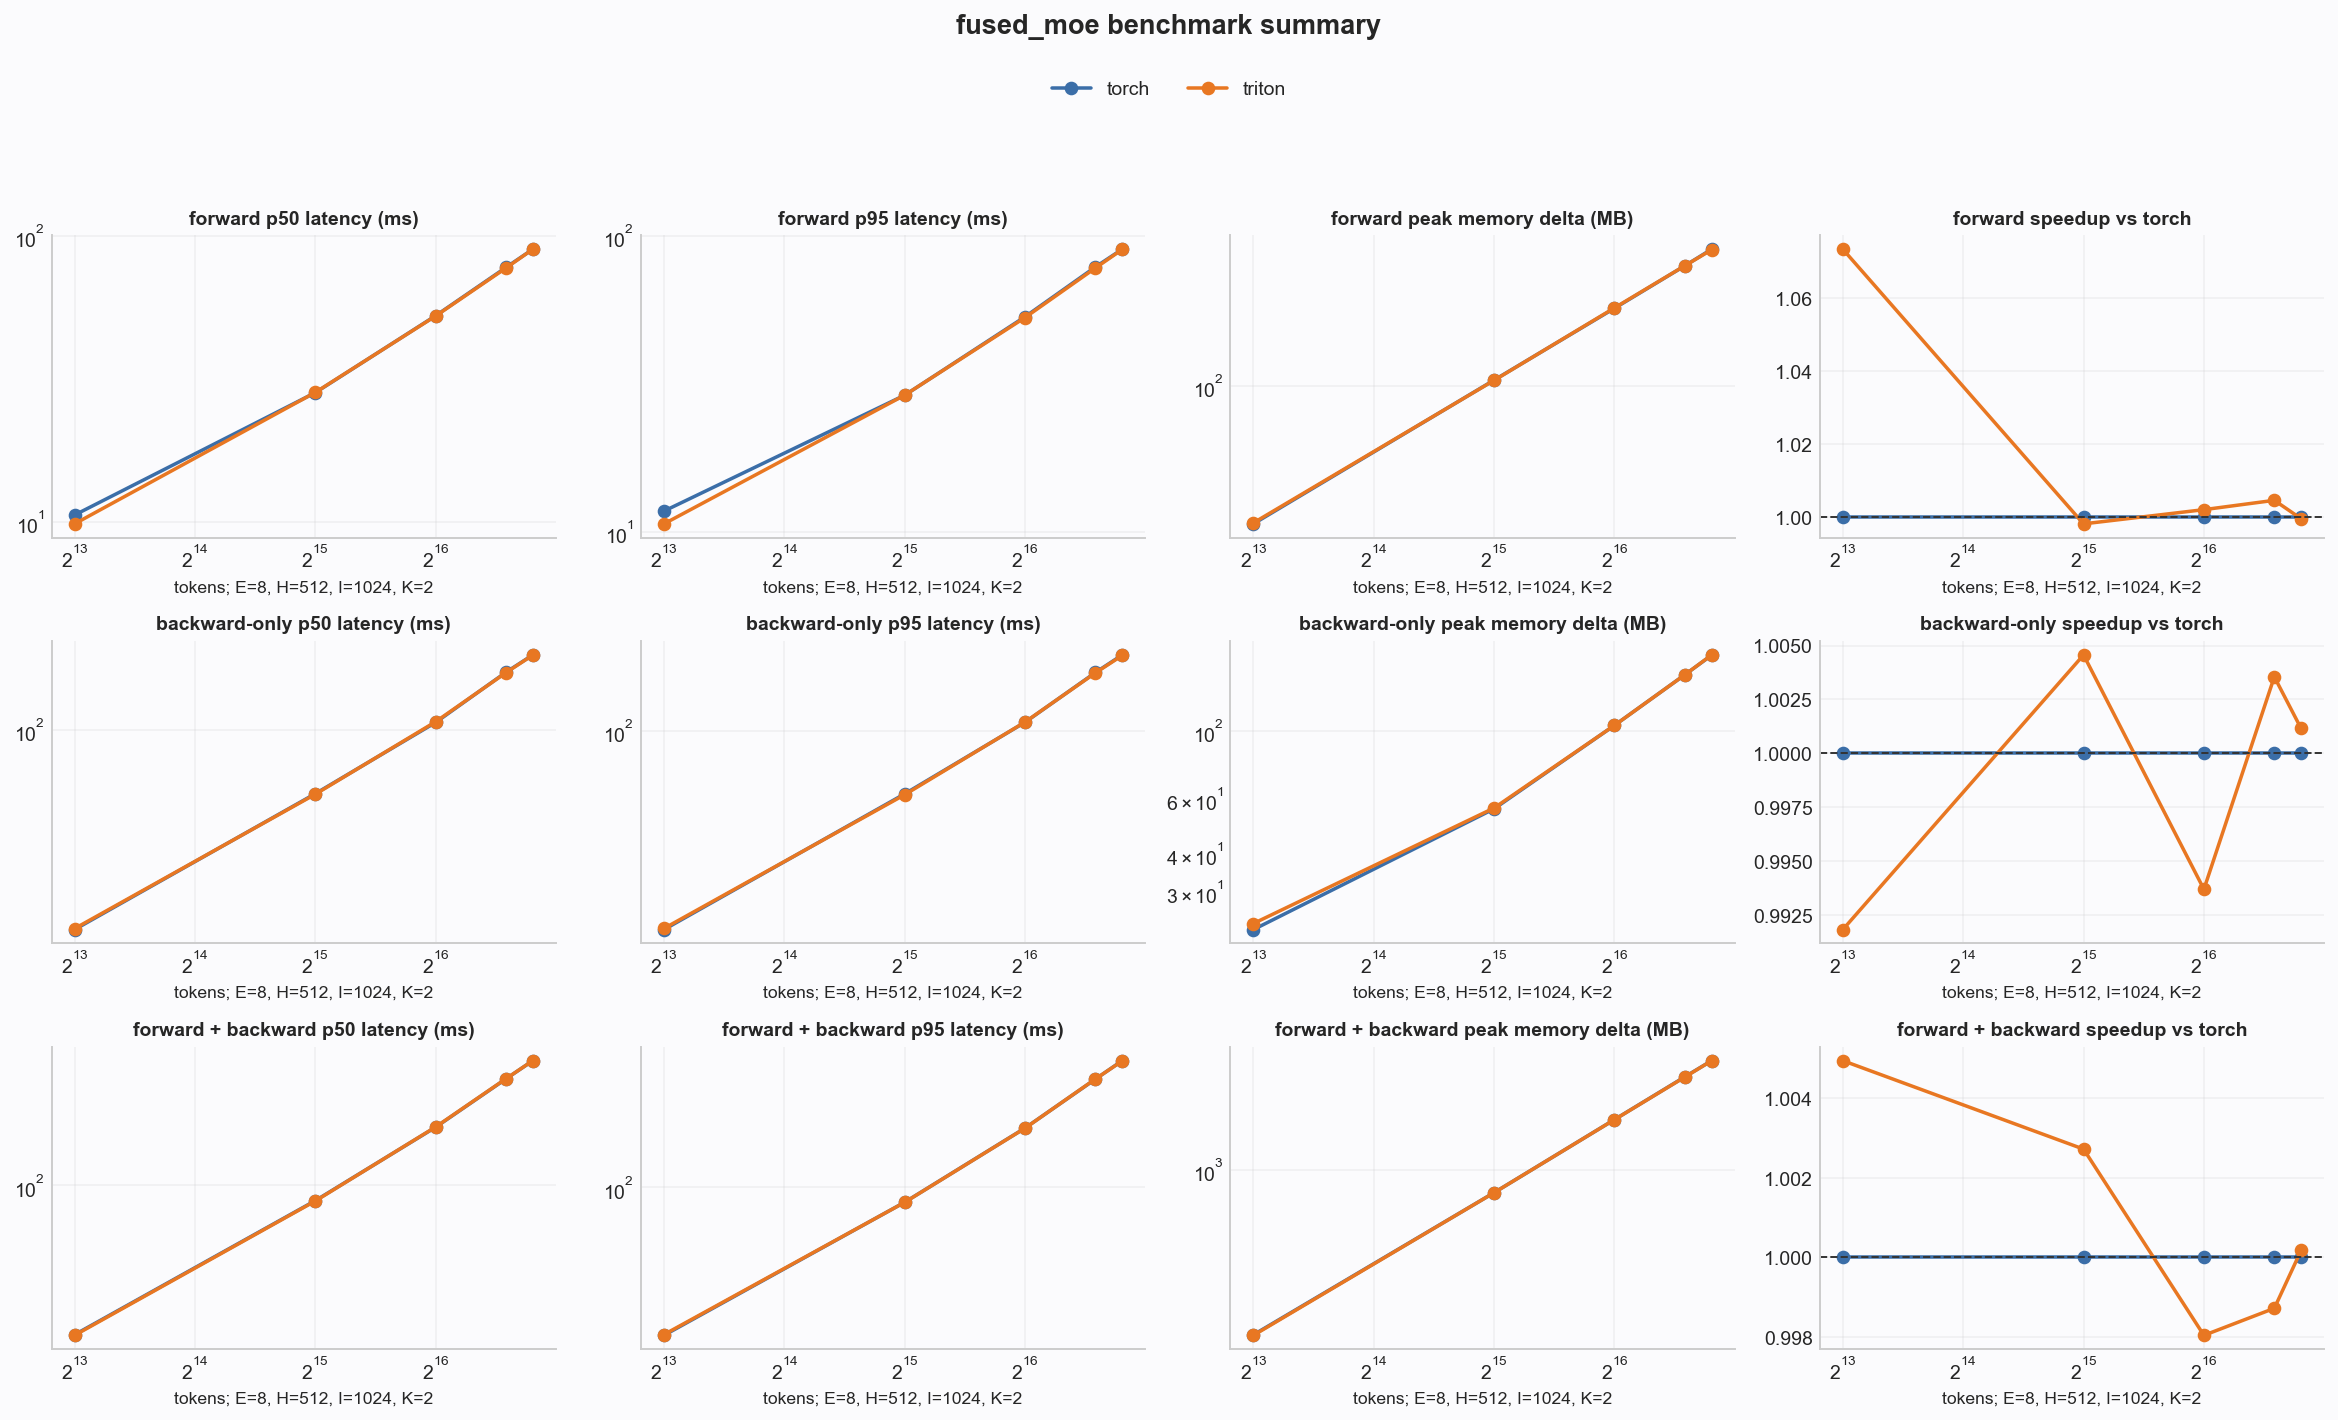

In [6]:
fused_moe_rows = bench_sweep(
    kernel='fused_moe',
    providers=PROVIDERS,
    sizes=(8192, 32768, 65536, 98304, 114688),
    size_label=f'tokens; E={NUM_EXPERTS}, H={HIDDEN}, I={INTERMEDIATE}, K={TOP_K}',
    make_case=make_fused_moe_case,
    forward=fused_moe_forward,
    warmup_ms=WARMUP_MS,
    rep_ms=REP_MS,
    atol=5e-2,
    rtol=5e-2,
)
cache_path = save_benchmark_results(
    fused_moe_rows, benchmark='fused_moe', cache_root=BENCHMARK_CACHE_DIR,
    metadata={'dtype': str(DTYPE), 'num_experts': NUM_EXPERTS, 'hidden': HIDDEN, 'intermediate': INTERMEDIATE, 'top_k': TOP_K},
)
print(f'raw benchmark data: {cache_path}')
display(to_summary_dataframe(fused_moe_rows))
_ = plot_kernel_grid(fused_moe_rows, save_path=FIG_DIR / 'fused_moe_summary.png')
